In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
np.random.seed(42)
n = 500
rng = np.random.default_rng(42)

In [4]:
# --- Base data ---
passengers = np.random.randint(200, 5000, n).astype(object)
delay_min = np.random.choice([np.nan, 0, 5, 10, 15, 30], n)
zone = list(np.random.choice(['North','South','East','West','Central'], n))
route_id = list(np.random.choice([f'R{i:02d}' for i in range(1,51)], n))
dates = list(pd.date_range('2022-01-01', periods=n, freq='D'))

In [5]:
# --- NOISE INJECTION (do NOT modify below) ---
idx = rng.choice(n, size=40, replace=False)
for i in idx[:15] : 
    passengers[i] = np.nan # missing values
for i in idx[15:25]:
    passengers[i] = str(passengers[i] or 0).split('.')[0] + ' pax' 
for i in idx[25:32]: 
    zone[i] = zone[i].lower() 
for i in idx[32:37]: 
    route_id[i] = ' ' + route_id[i] + ' ' 
for i in idx[37:40]: 
    delay_min[i] = -999 
for i in rng.choice(n, 8): 
    passengers[i] = 99999 

In [6]:
df = pd.DataFrame({'route_id': route_id, 'date': dates,
 'passengers': passengers, 'delay_min': delay_min, 'zone': zone})

In [7]:
df.to_csv("dataset")

In [8]:
df["passengers"] = (df["passengers"].astype(str).str.replace(" pax", "", regex=False))

In [9]:
df["passengers"] = pd.to_numeric(df["passengers"], errors="coerce")

In [10]:
median_passengers = df["passengers"].median()
df["passengers"] = df["passengers"].fillna(median_passengers)

In [11]:
mean = df["passengers"].mean()
std = df["passengers"].std()
upper_limit = mean + 3 * std
p99 = df["passengers"].quantile(0.99)

In [12]:
df.loc[df["passengers"] > upper_limit, "passengers"] = p99

In [13]:
#Task 2
df["delay_min"] = df["delay_min"].replace(-999, np.nan)
route_median = df.groupby("route_id")["delay_min"].transform("median")
df["delay_min"] = df["delay_min"].fillna(route_median)

In [14]:
df.isnull().sum()

route_id      0
date          0
passengers    0
delay_min     1
zone          0
dtype: int64

In [15]:
route_median = df.groupby("route_id")["delay_min"].transform("median")
df["delay_min"] = df["delay_min"].fillna(route_median)

In [16]:
df["delay_min"] = df["delay_min"].fillna(df["delay_min"].median())

In [17]:
df["zone"] = (df["zone"].astype(str).str.strip().str.title())

In [18]:
valid_zones = ["North", "South", "East", "West", "Central"]
df.loc[~df["zone"].isin(valid_zones), "zone"] = np.nan

In [19]:
df["zone"] = df["zone"].fillna(df["zone"].mode()[0])
df["route_id"] = df["route_id"].astype(str).str.strip()

In [20]:
df["peak_load"] = np.select(
    [df["passengers"] > 3500,(df["passengers"] >= 1500) & (df["passengers"] <= 3500)],
    [ "High","Medium"],
    default="Low"
)

In [21]:
df["day_of_week"] = df["date"].dt.day_name()

In [22]:
df.to_csv("cleaned_dataset.csv", index=False)

In [23]:
route_stats = (df.groupby("route_id").agg(avg_passengers=("passengers", "mean"),avg_delay=("delay_min", "mean")).reset_index())
route_stats

,route_id,avg_passengers,avg_delay
0,R01,2220.777778,12.777778
1,R02,2958.750000,17.916667
2,R03,2542.666667,16.666667
3,R04,2438.166667,14.166667
4,R05,2866.375000,13.125000
5,R06,2526.166667,11.250000
6,R07,2789.428571,16.428571
7,R08,2826.071429,15.357143
8,R09,2194.000000,13.000000
9,R10,3304.111111,11.666667


In [24]:
route_list = [(row.route_id, row.avg_passengers, row.avg_delay)for row in route_stats.itertuples(index=False)]
route_list

[('R01', 2220.777777777778, 12.777777777777779),
 ('R02', 2958.75, 17.916666666666668),
 ('R03', 2542.6666666666665, 16.666666666666668),
 ('R04', 2438.1666666666665, 14.166666666666666),
 ('R05', 2866.375, 13.125),
 ('R06', 2526.1666666666665, 11.25),
 ('R07', 2789.4285714285716, 16.428571428571427),
 ('R08', 2826.0714285714284, 15.357142857142858),
 ('R09', 2194.0, 13.0),
 ('R10', 3304.1111111111113, 11.666666666666666),
 ('R11', 2803.5454545454545, 12.272727272727273),
 ('R12', 8560.35294117647, 7.647058823529412),
 ('R13', 2582.285714285714, 11.428571428571429),
 ('R14', 2691.3333333333335, 12.916666666666666),
 ('R15', 2954.0, 10.384615384615385),
 ('R16', 2623.0, 14.642857142857142),
 ('R17', 12123.181818181818, 12.727272727272727),
 ('R18', 1857.8, 6.5),
 ('R19', 2101.8, 15.0),
 ('R20', 2003.4705882352941, 11.470588235294118),
 ('R21', 2759.6, 13.0),
 ('R22', 2160.7272727272725, 13.181818181818182),
 ('R23', 2234.4285714285716, 12.142857142857142),
 ('R24', 2791.875, 15.0),
 ('R

In [25]:
def merge(left, right, key_index, reverse=True):
    merged = []
    i = j = 0

    while i < len(left) and j < len(right):
        if reverse:
            if left[i][key_index] >= right[j][key_index]:
                merged.append(left[i])
                i += 1
            else:
                merged.append(right[j])
                j += 1
        else:
            if left[i][key_index] <= right[j][key_index]:
                merged.append(left[i])
                i += 1
            else:
                merged.append(right[j])
                j += 1

    merged.extend(left[i:])
    merged.extend(right[j:])
    return merged


In [26]:
def merge_sort(arr, key_index, reverse=True):
    if len(arr) <= 1:
        return arr

    mid = len(arr) // 2

    left = merge_sort(arr[:mid], key_index, reverse)
    right = merge_sort(arr[mid:], key_index, reverse)

    return merge(left, right, key_index, reverse)
def merge_sort(arr, key_index, reverse=True):
    if len(arr) <= 1:
        return arr

    mid = len(arr) // 2

    left = merge_sort(arr[:mid], key_index, reverse)
    right = merge_sort(arr[mid:], key_index, reverse)

    return merge(left, right, key_index, reverse)


In [27]:
sorted_by_passengers = merge_sort(route_list, key_index=1, reverse=True)

print("\nTop 5 Routes by Average Passengers")
print(f"{'Route':<10}{'Avg Passengers':>18}{'Avg Delay':>15}")

for r in sorted_by_passengers[:5]:
    print(f"{r[0]:<10}{r[1]:>18.2f}{r[2]:>15.2f}")


Top 5 Routes by Average Passengers
Route         Avg Passengers      Avg Delay
R41                 17122.07          11.43
R49                 13416.11           8.33
R26                 13170.90           1.50
R45                 12297.70          13.00
R17                 12123.18          12.73


In [28]:
efficiency_list = []

for route_id, avg_passengers, avg_delay in route_list:
    efficiency_score = avg_passengers / (1 + avg_delay)
    efficiency_list.append(
        (route_id, avg_passengers, avg_delay, efficiency_score)
    )

# Rank by efficiency score
sorted_efficiency = merge_sort(efficiency_list, key_index=3, reverse=True)
sorted_efficiency

[('R26', 13170.9, 1.5, 5268.36),
 ('R48', 3244.75, 0.0, 3244.75),
 ('R49', 13416.111111111111, 8.333333333333334, 1437.4404761904761),
 ('R41', 17122.071428571428, 11.428571428571429, 1377.6379310344826),
 ('R12', 8560.35294117647, 7.647058823529412, 989.972789115646),
 ('R17', 12123.181818181818, 12.727272727272727, 883.1456953642385),
 ('R45', 12297.7, 13.0, 878.407142857143),
 ('R33', 11011.833333333334, 12.5, 815.6913580246915),
 ('R27', 3461.4285714285716, 8.571428571428571, 361.64179104477614),
 ('R37', 2816.3636363636365, 7.2727272727272725, 340.4395604395604),
 ('R34', 3195.6, 9.0, 319.56),
 ('R36', 3132.7272727272725, 8.863636363636363, 317.6036866359447),
 ('R10', 3304.1111111111113, 11.666666666666666, 260.85087719298247),
 ('R15', 2954.0, 10.384615384615385, 259.47297297297297),
 ('R18', 1857.8, 6.5, 247.70666666666665),
 ('R28', 3178.1, 12.5, 235.4148148148148),
 ('R32', 2688.214285714286, 11.071428571428571, 222.6923076923077),
 ('R44', 2750.0, 11.363636363636363, 222.426

In [29]:
print("\nTop 5 Routes by Efficiency Score")
print("-" * 70)
print(f"{'Route':<10}{'Passengers':>15}{'Delay':>12}{'Efficiency':>18}")
for r in sorted_efficiency[:5]:
    print(f"{r[0]:<10}{r[1]:>15.2f}{r[2]:>12.2f}{r[3]:>18.2f}")
print("\nBottom 5 Routes by Efficiency Score")
print("-" * 70)
print(f"{'Route':<10}{'Passengers':>15}{'Delay':>12}{'Efficiency':>18}")
for r in sorted_efficiency[-5:]:
    print(f"{r[0]:<10}{r[1]:>15.2f}{r[2]:>12.2f}{r[3]:>18.2f}")



Top 5 Routes by Efficiency Score
----------------------------------------------------------------------
Route          Passengers       Delay        Efficiency
R26              13170.90        1.50           5268.36
R48               3244.75        0.00           3244.75
R49              13416.11        8.33           1437.44
R41              17122.07       11.43           1377.64
R12               8560.35        7.65            989.97

Bottom 5 Routes by Efficiency Score
----------------------------------------------------------------------
Route          Passengers       Delay        Efficiency
R03               2542.67       16.67            143.92
R42               2381.00       15.62            143.22
R47               2331.57       15.36            142.54
R19               2101.80       15.00            131.36
R31               1484.22       12.78            107.73


In [30]:
for i in range(len(sorted_efficiency) - 1):
    assert (
        sorted_efficiency[i][3] >= sorted_efficiency[i + 1][3]
    ), "Merge Sort verification failed!"

print("\n Merge Sort verification passed!")
print("Efficiency scores are in non-increasing order.")


 Merge Sort verification passed!
Efficiency scores are in non-increasing order.


Daily           date  passengers
0   2022-01-01      1060.0
1   2022-01-02      3972.0
2   2022-01-03      3292.0
3   2022-01-04       666.0
4   2022-01-05      4626.0
..         ...         ...
495 2023-05-11      2739.0
496 2023-05-12      3524.0
497 2023-05-13      3501.0
498 2023-05-14      1742.0
499 2023-05-15      1391.0

[500 rows x 2 columns]
rolling: 0      1060.000000
1      2516.000000
2      2774.666667
3      2247.500000
4      2723.200000
          ...     
495    2733.285714
496    2737.571429
497    2533.571429
498    2588.714286
499    2654.285714
Name: passengers, Length: 500, dtype: float64


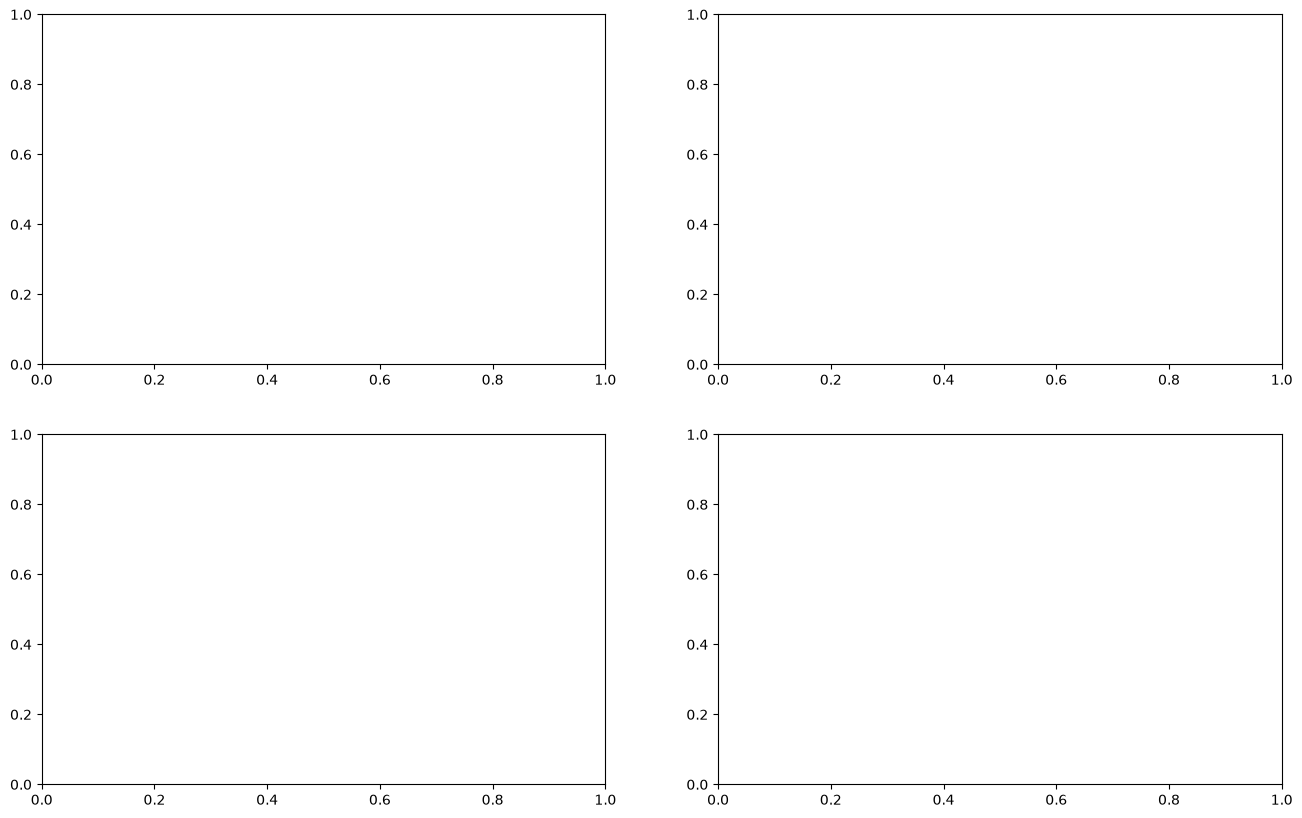

In [31]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
daily = (df.groupby("date")["passengers"].sum().reset_index())
print("Daily",daily)
rolling = daily["passengers"].rolling(window=7, min_periods=1).mean()
print("rolling:",rolling)

In [32]:
axes[0, 0].plot(daily["date"],daily["passengers"],label="Daily Passengers",color="steelblue",linewidth=1.5)
axes[0, 0].plot(daily["date"],rolling,label="7-Day Rolling Mean",color="red",linewidth=2)
axes[0, 0].set_title("Daily Total Passengers")
axes[0, 0].set_xlabel("Date")
axes[0, 0].set_ylabel("Passengers")
axes[0, 0].legend()

In [33]:
grouped = (
    df.groupby(["zone", "peak_load"])["passengers"].mean().unstack(fill_value=0))
print(grouped)
zones = grouped.index
x = np.arange(len(zones))
width = 0.25
peak_levels = ["Low", "Medium", "High"]

for i, level in enumerate(peak_levels):
    values = grouped[level] if level in grouped.columns else np.zeros(len(zones))
    axes[0, 1].bar(
        x + (i - 1) * width,
        values,
        width,
        label=level
    )

axes[0, 1].set_xticks(x)
axes[0, 1].set_xticklabels(zones)
axes[0, 1].set_title("Average Passengers by Zone and Peak Load")
axes[0, 1].set_xlabel("Zone")
axes[0, 1].set_ylabel("Average Passengers")
axes[0, 1].legend()

peak_load          High         Low       Medium
zone                                            
Central     9441.921053  955.764706  2616.885714
East        4201.789474  873.666667  2742.239130
North       7573.103448  929.041667  2629.529412
South      10732.000000  945.920000  2543.224490
West       16668.260870  757.947368  2524.076923


In [34]:
delay = df["delay_min"].dropna()
mean = np.mean(delay)
std = np.std(delay)

axes[1, 0].hist(
    delay,
    bins=20,
    density=True,
    alpha=0.7,
    color="skyblue",
    edgecolor="black",
    label="Observed"
)

x = np.linspace(delay.min(), delay.max(), 300)

normal = (
    1 / (std * np.sqrt(2 * np.pi))
) * np.exp(
    -(x - mean) ** 2 / (2 * std ** 2)
)

axes[1, 0].plot(
    x,
    normal,
    color="red",
    linewidth=2,
    label="Normal Curve"
)

axes[1, 0].set_title("Delay Distribution")
axes[1, 0].set_xlabel("Delay (minutes)")
axes[1, 0].set_ylabel("Density")
axes[1, 0].legend()

In [35]:
route_summary = (
    df.groupby("route_id")
      .agg(
          avg_passengers=("passengers", "mean"),
          avg_delay=("delay_min", "mean"),
          zone=("zone", lambda x: x.mode()[0])
      )
      .reset_index()
)

colors = {
    "North": "blue",
    "South": "green",
    "East": "orange",
    "West": "purple",
    "Central": "red"
}

for zone in colors:
    subset = route_summary[route_summary["zone"] == zone]

    axes[1, 1].scatter(
        subset["avg_passengers"],
        subset["avg_delay"],
        color=colors[zone],
        label=zone,
        alpha=0.75,
        s=60
    )

top10 = route_summary.nlargest(10, "avg_passengers")

for _, row in top10.iterrows():
    axes[1, 1].text(
        row["avg_passengers"],
        row["avg_delay"],
        row["route_id"],
        fontsize=8
    )

axes[1, 1].set_title("Route Performance")
axes[1, 1].set_xlabel("Average Passengers")
axes[1, 1].set_ylabel("Average Delay (minutes)")
axes[1, 1].legend(title="Zone")


In [36]:
plt.tight_layout()
plt.savefig("mobility_dashboard.png",dpi=150,bbox_inches="tight")
plt.show()

<Figure size 640x480 with 0 Axes>

In [37]:
import folium
from folium.plugins import HeatMap

In [38]:
ZONE_COORDS = {
    'North': [28.8000, 77.2090],
    'South': [28.4595, 77.0266],
    'East': [28.6139, 77.3910],
    'West': [28.6139, 77.0270],
    'Central': [28.6139, 77.2090],
}

In [39]:

city_map = folium.Map(location=[28.6139, 77.2090],zoom_start=11)

In [40]:
zone_stats = (
    df.groupby("zone")
      .agg(
          avg_passengers=("passengers", "mean"),
          avg_delay=("delay_min", "mean"),
          dominant_peak=("peak_load", lambda x: x.mode()[0])
      )
)
marker_count = 0

In [41]:
for zone, row in zone_stats.iterrows():

    lat, lon = ZONE_COORDS[zone]

    avg_passengers = row["avg_passengers"]
    avg_delay = row["avg_delay"]
    dominant_peak = row["dominant_peak"]

    # Marker color
    if avg_passengers < 2000:
        color = "green"
    elif avg_passengers <= 3500:
        color = "orange"
    else:
        color = "red"

    radius = avg_passengers / 200

    popup = folium.Popup(
        f"""
        <b>Zone:</b> {zone}<br>
        <b>Avg Passengers:</b> {avg_passengers:.2f}<br>
        <b>Avg Delay:</b> {avg_delay:.2f} min<br>
        <b>Dominant Peak Load:</b> {dominant_peak}
        """,
        max_width=250
    )

    folium.CircleMarker(
        location=[lat, lon],
        radius=radius,
        color=color,
        fill=True,
        fill_color=color,
        fill_opacity=0.75,
        popup=popup
    ).add_to(city_map)

    marker_count += 1

In [42]:
heat_data = []

rng = np.random.default_rng(42)

for _, row in df.iterrows():

    lat, lon = ZONE_COORDS[row["zone"]]

    # Random jitter ±0.02 degrees
    lat += rng.uniform(-0.02, 0.02)
    lon += rng.uniform(-0.02, 0.02)

    heat_data.append([lat, lon, row["passengers"]])

HeatMap(
    heat_data,
    radius=15,
    blur=10,
    max_zoom=13
).add_to(city_map)

In [43]:
city_map.save("city_mobility_map.html")

print(f"Map saved as 'city_mobility_map.html'")
print(f"Total markers added: {marker_count}")

Map saved as 'city_mobility_map.html'
Total markers added: 5
